In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("loanapproval.csv")

In [3]:
df.head()

,applicant_id,age,gender,marital_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,employment_status,loan_approved
0,1,59,Male,Divorced,100073,7169,793,1,1,Unemployed,1
1,2,49,Male,Married,112197,23556,789,0,2,Employed,1
2,3,35,Male,Divorced,84429,27052,372,1,4,Unemployed,0
3,4,63,Female,Single,124195,11313,808,3,4,Self-employed,1
4,5,28,Female,Married,81627,13315,689,0,1,Unemployed,1


In [4]:
df.tail()

,applicant_id,age,gender,marital_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,employment_status,loan_approved
995,996,53,Female,Married,135598,6014,767,3,2,Employed,1
996,997,22,Male,Single,139028,15103,662,0,0,Self-employed,1
997,998,34,Female,Married,147517,21986,582,0,2,Employed,1
998,999,60,Female,Divorced,73161,49781,635,4,0,Unemployed,1
999,1000,60,Female,Single,141316,35471,461,1,1,Unemployed,1


In [5]:
df.shape

(1000, 11)

In [6]:
df.columns

Index(['applicant_id', 'age', 'gender', 'marital_status', 'annual_income',
       'loan_amount', 'credit_score', 'num_dependents', 'existing_loans_count',
       'employment_status', 'loan_approved'],
      dtype='object')

In [7]:
df.dtypes

applicant_id             int64
age                      int64
gender                  object
marital_status          object
annual_income            int64
loan_amount              int64
credit_score             int64
num_dependents           int64
existing_loans_count     int64
employment_status       object
loan_approved            int64
dtype: object

In [8]:
df.describe()

,applicant_id,age,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,loan_approved
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,42.515000,81972.972000,27244.866000,576.125000,1.97700,2.042000,0.729000
std,288.819436,12.611059,37547.255418,12822.752877,155.921483,1.41862,1.413589,0.444699
min,1.000000,21.000000,20155.000000,5082.000000,300.000000,0.00000,0.000000,0.000000
25%,250.750000,32.000000,48913.250000,16587.500000,443.750000,1.00000,1.000000,0.000000
50%,500.500000,43.000000,82050.000000,27041.500000,573.500000,2.00000,2.000000,1.000000
75%,750.250000,53.000000,113556.000000,37939.250000,713.250000,3.00000,3.000000,1.000000
max,1000.000000,64.000000,149951.000000,49864.000000,849.000000,4.00000,4.000000,1.000000


In [9]:
df.isnull().sum()

applicant_id            0
age                     0
gender                  0
marital_status          0
annual_income           0
loan_amount             0
credit_score            0
num_dependents          0
existing_loans_count    0
employment_status       0
loan_approved           0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
for col in df.columns:
    print(f"\n{col}")
    print(df[col].unique())


applicant_id
[   1    2    3    4    5    6    7    8    9   10   11   12   13   14
   15   16   17   18   19   20   21   22   23   24   25   26   27   28
   29   30   31   32   33   34   35   36   37   38   39   40   41   42
   43   44   45   46   47   48   49   50   51   52   53   54   55   56
   57   58   59   60   61   62   63   64   65   66   67   68   69   70
   71   72   73   74   75   76   77   78   79   80   81   82   83   84
   85   86   87   88   89   90   91   92   93   94   95   96   97   98
   99  100  101  102  103  104  105  106  107  108  109  110  111  112
  113  114  115  116  117  118  119  120  121  122  123  124  125  126
  127  128  129  130  131  132  133  134  135  136  137  138  139  140
  141  142  143  144  145  146  147  148  149  150  151  152  153  154
  155  156  157  158  159  160  161  162  163  164  165  166  167  168
  169  170  171  172  173  174  175  176  177  178  179  180  181  182
  183  184  185  186  187  188  189  190  191  192  193  194  1

In [12]:
df["loan_approved"].value_counts()

loan_approved
1    729
0    271
Name: count, dtype: int64

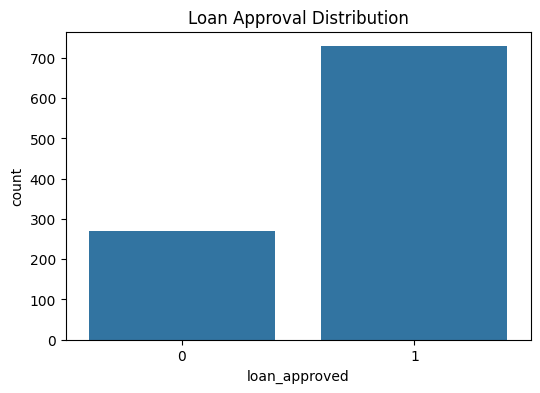

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(x="loan_approved", data=df)

plt.title("Loan Approval Distribution")

plt.show()

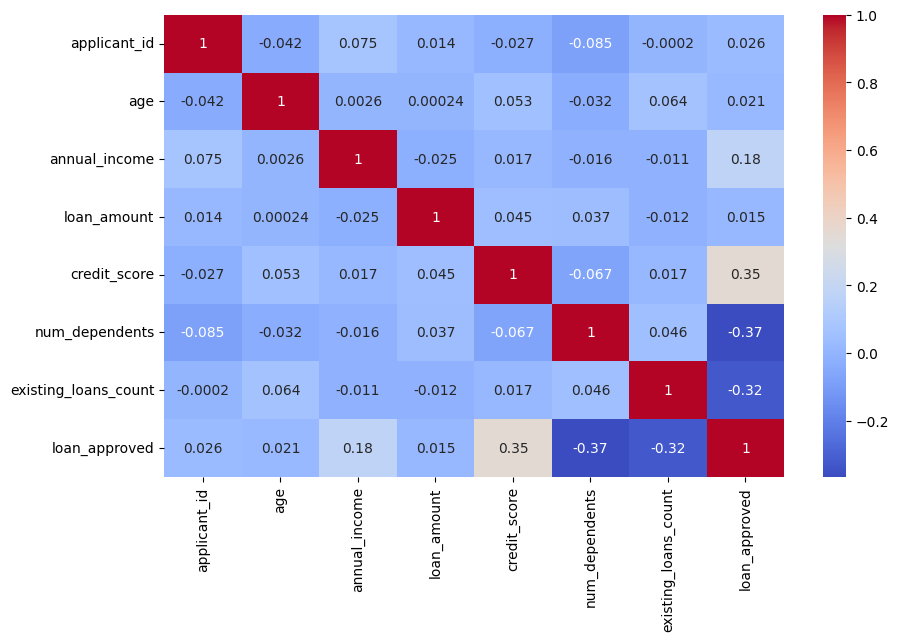

In [14]:
plt.figure(figsize=(10,6))

sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap="coolwarm")

plt.show()

In [15]:
df_processed = df.copy()

In [16]:
id_columns = [col for col in df_processed.columns if "id" in col.lower()]

df_processed.drop(columns=id_columns, inplace=True)

df_processed.head()

,age,gender,marital_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,employment_status,loan_approved
0,59,Male,Divorced,100073,7169,793,1,1,Unemployed,1
1,49,Male,Married,112197,23556,789,0,2,Employed,1
2,35,Male,Divorced,84429,27052,372,1,4,Unemployed,0
3,63,Female,Single,124195,11313,808,3,4,Self-employed,1
4,28,Female,Married,81627,13315,689,0,1,Unemployed,1


In [17]:
df_processed.shape

(1000, 10)

In [18]:
df_processed.drop_duplicates(inplace=True)

print("Shape :", df_processed.shape)

Shape : (1000, 10)


In [19]:
numerical_columns = df_processed.select_dtypes(include=["int64", "float64"]).columns

categorical_columns = df_processed.select_dtypes(include=["object"]).columns

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
Index(['age', 'annual_income', 'loan_amount', 'credit_score', 'num_dependents',
       'existing_loans_count', 'loan_approved'],
      dtype='object')

Categorical Columns:
Index(['gender', 'marital_status', 'employment_status'], dtype='object')


In [20]:
for col in numerical_columns:
    df_processed[col].fillna(df_processed[col].median(), inplace=True)

In [21]:
for col in categorical_columns:
    df_processed[col].fillna(df_processed[col].mode()[0], inplace=True)

In [22]:
df_processed.isnull().sum()

age                     0
gender                  0
marital_status          0
annual_income           0
loan_amount             0
credit_score            0
num_dependents          0
existing_loans_count    0
employment_status       0
loan_approved           0
dtype: int64

In [23]:
from sklearn.preprocessing import LabelEncoder

In [24]:
label_encoders = {}

In [25]:
for col in categorical_columns:
    le = LabelEncoder()

    df_processed[col] = le.fit_transform(df_processed[col])

    label_encoders[col] = le

In [26]:
df_processed.dtypes

age                     int64
gender                  int64
marital_status          int64
annual_income           int64
loan_amount             int64
credit_score            int64
num_dependents          int64
existing_loans_count    int64
employment_status       int64
loan_approved           int64
dtype: object

In [27]:
df_processed.head()

,age,gender,marital_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,employment_status,loan_approved
0,59,1,0,100073,7169,793,1,1,2,1
1,49,1,1,112197,23556,789,0,2,0,1
2,35,1,0,84429,27052,372,1,4,2,0
3,63,0,2,124195,11313,808,3,4,1,1
4,28,0,1,81627,13315,689,0,1,2,1


In [28]:
import os

os.makedirs("cleaned_data", exist_ok=True)

df_processed.to_csv(
    "cleaned_data/loanapproval_processed.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [29]:
import pandas as pd

processed_df = pd.read_csv("cleaned_data/loanapproval_processed.csv")

processed_df.head()

,age,gender,marital_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,employment_status,loan_approved
0,59,1,0,100073,7169,793,1,1,2,1
1,49,1,1,112197,23556,789,0,2,0,1
2,35,1,0,84429,27052,372,1,4,2,0
3,63,0,2,124195,11313,808,3,4,1,1
4,28,0,1,81627,13315,689,0,1,2,1


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [31]:
print("Dataset Shape :", df_processed.shape)

print("\nColumns")
print(df_processed.columns.tolist())

print("\nData Types")
print(df_processed.dtypes)

print("\nMissing Values")
print(df_processed.isnull().sum())

Dataset Shape : (1000, 10)

Columns
['age', 'gender', 'marital_status', 'annual_income', 'loan_amount', 'credit_score', 'num_dependents', 'existing_loans_count', 'employment_status', 'loan_approved']

Data Types
age                     int64
gender                  int64
marital_status          int64
annual_income           int64
loan_amount             int64
credit_score            int64
num_dependents          int64
existing_loans_count    int64
employment_status       int64
loan_approved           int64
dtype: object

Missing Values
age                     0
gender                  0
marital_status          0
annual_income           0
loan_amount             0
credit_score            0
num_dependents          0
existing_loans_count    0
employment_status       0
loan_approved           0
dtype: int64


In [32]:
df_processed.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1000.0,42.515,12.611059,21.0,32.00,43.0,53.00,64.0
gender,1000.0,0.524,0.499674,0.0,0.00,1.0,1.00,1.0
marital_status,1000.0,1.039,0.802573,0.0,0.00,1.0,2.00,2.0
annual_income,1000.0,81972.972,37547.255418,20155.0,48913.25,82050.0,113556.00,149951.0
loan_amount,1000.0,27244.866,12822.752877,5082.0,16587.50,27041.5,37939.25,49864.0
credit_score,1000.0,576.125,155.921483,300.0,443.75,573.5,713.25,849.0
num_dependents,1000.0,1.977,1.418620,0.0,1.00,2.0,3.00,4.0
existing_loans_count,1000.0,2.042,1.413589,0.0,1.00,2.0,3.00,4.0
employment_status,1000.0,1.010,0.806567,0.0,0.00,1.0,2.00,2.0
loan_approved,1000.0,0.729,0.444699,0.0,0.00,1.0,1.00,1.0


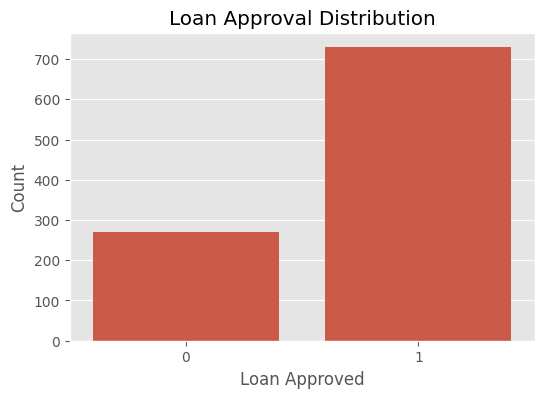

In [33]:
plt.figure(figsize=(6,4))

sns.countplot(x="loan_approved", data=df_processed)

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Approved")
plt.ylabel("Count")

plt.show()

In [34]:
numerical_columns = [
    col for col in df_processed.columns
    if col != "loan_approved"
]

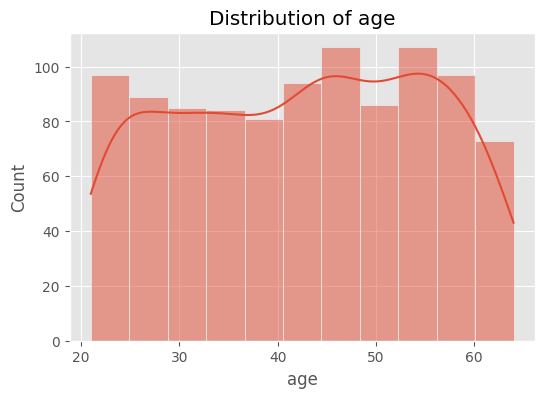

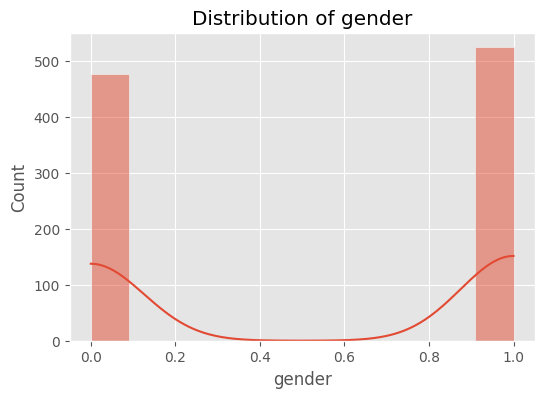

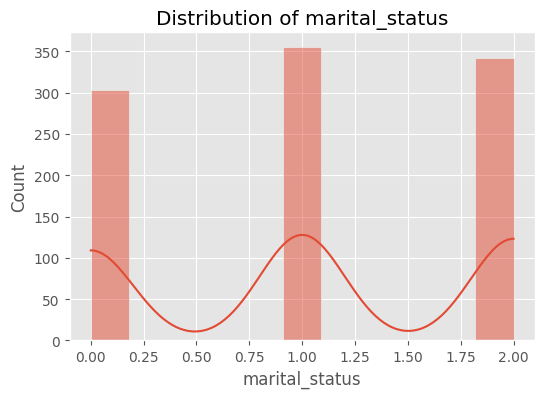

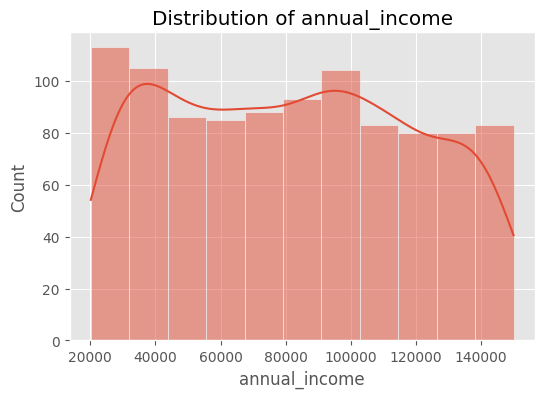

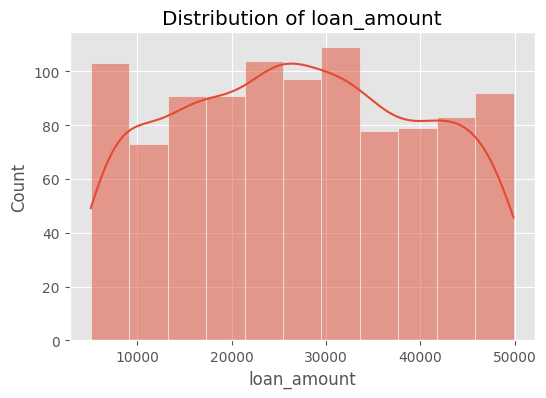

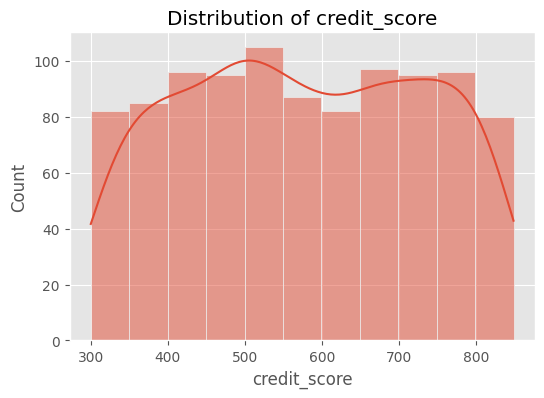

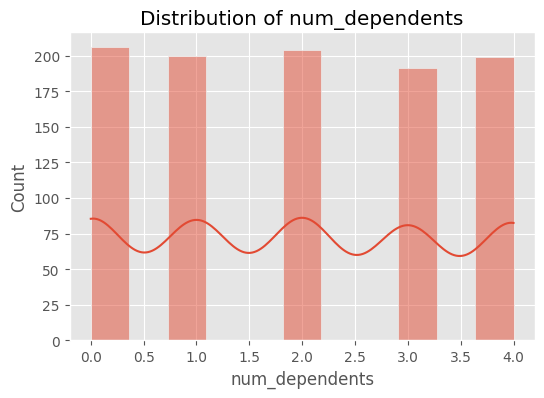

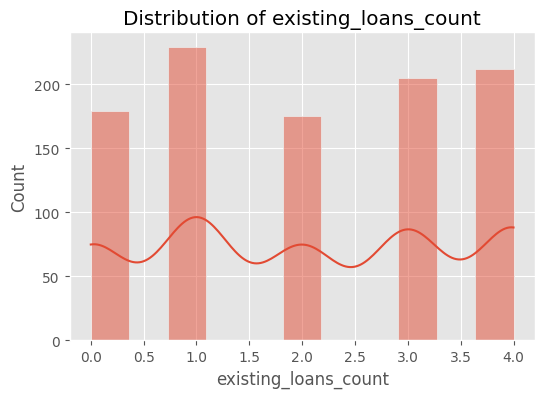

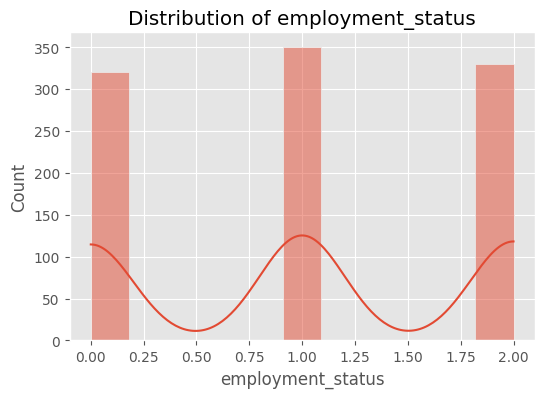

In [35]:
for col in numerical_columns:

    plt.figure(figsize=(6,4))

    sns.histplot(df_processed[col], kde=True)

    plt.title(f"Distribution of {col}")

    plt.show()

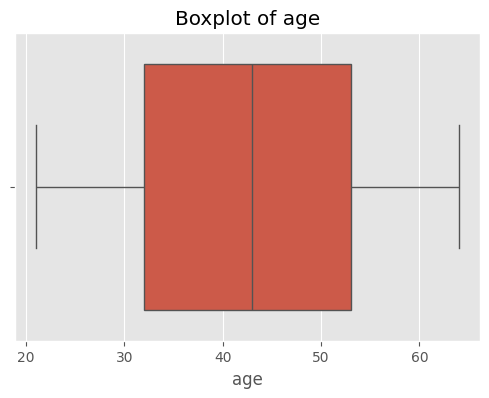

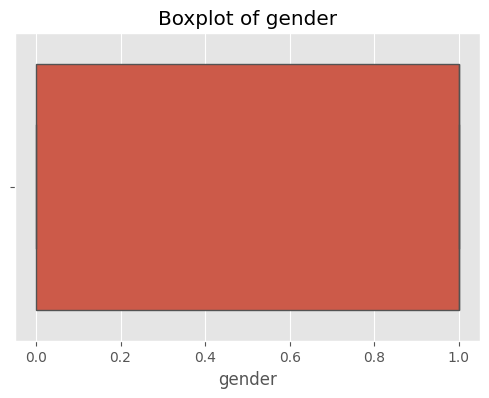

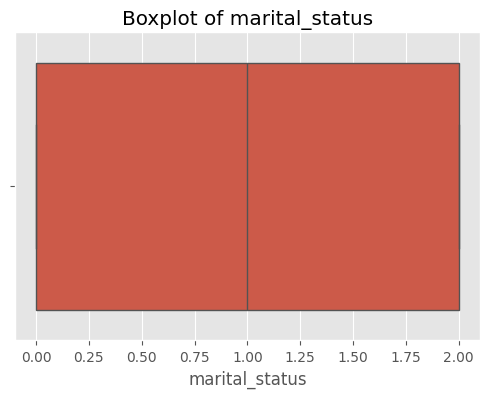

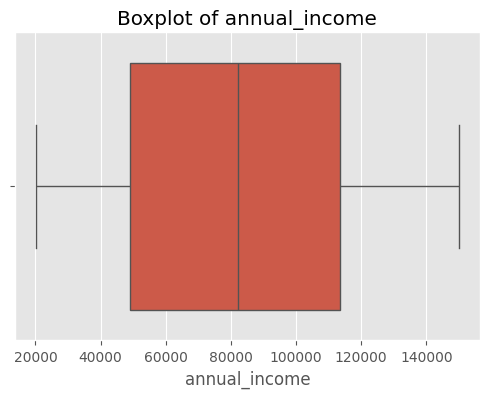

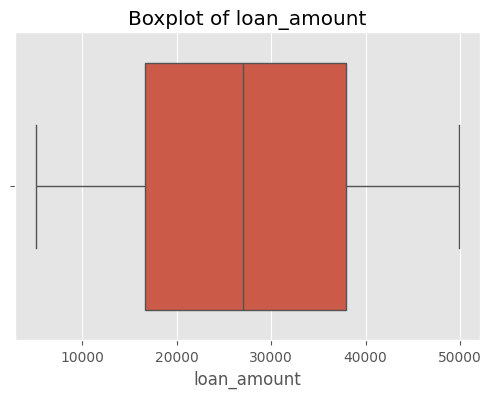

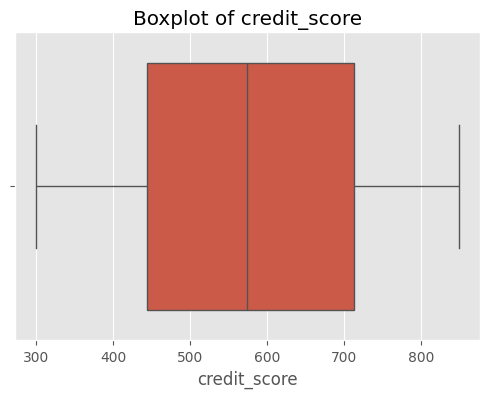

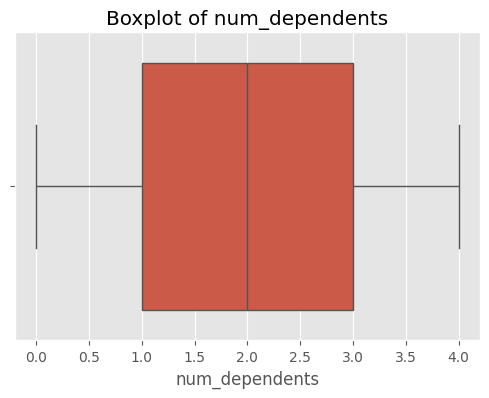

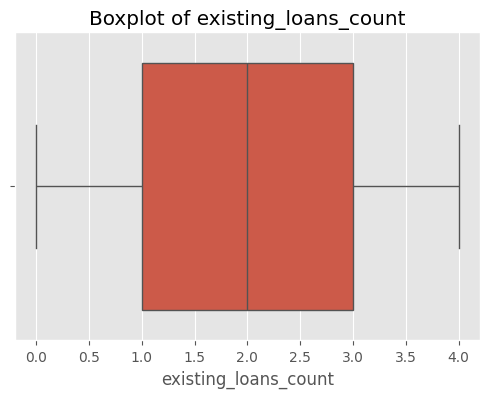

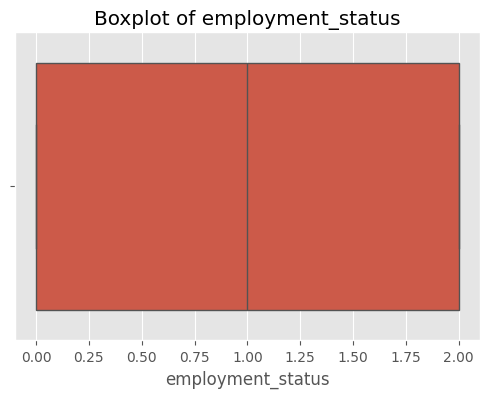

In [36]:
for col in numerical_columns:

    plt.figure(figsize=(6,4))

    sns.boxplot(x=df_processed[col])

    plt.title(f"Boxplot of {col}")

    plt.show()

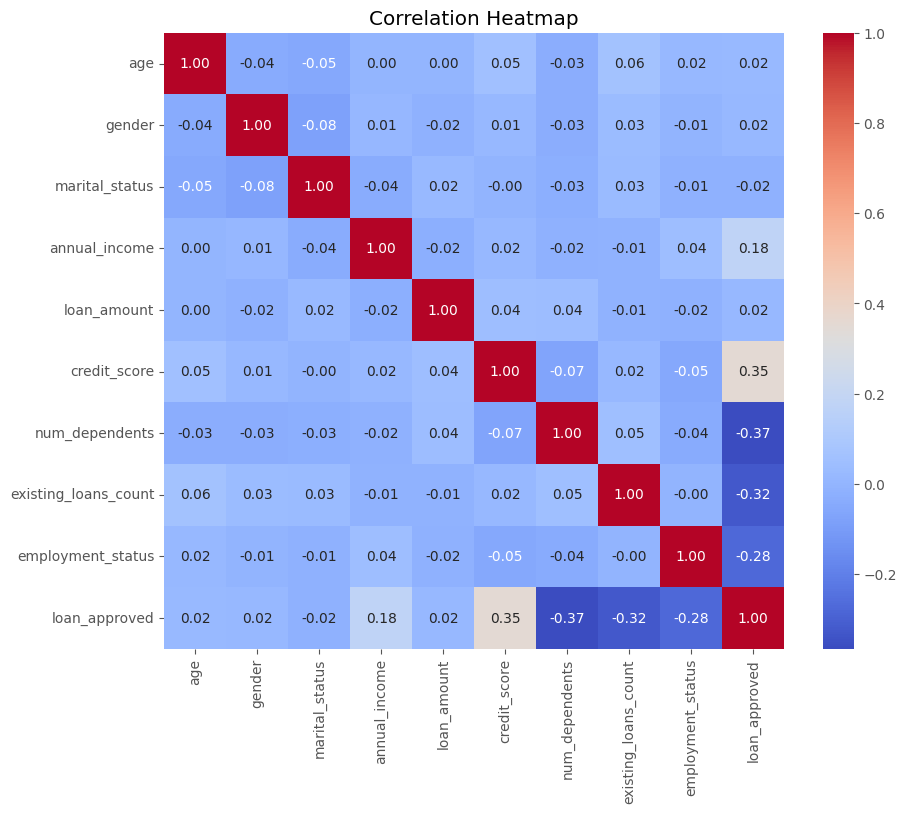

In [37]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df_processed.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

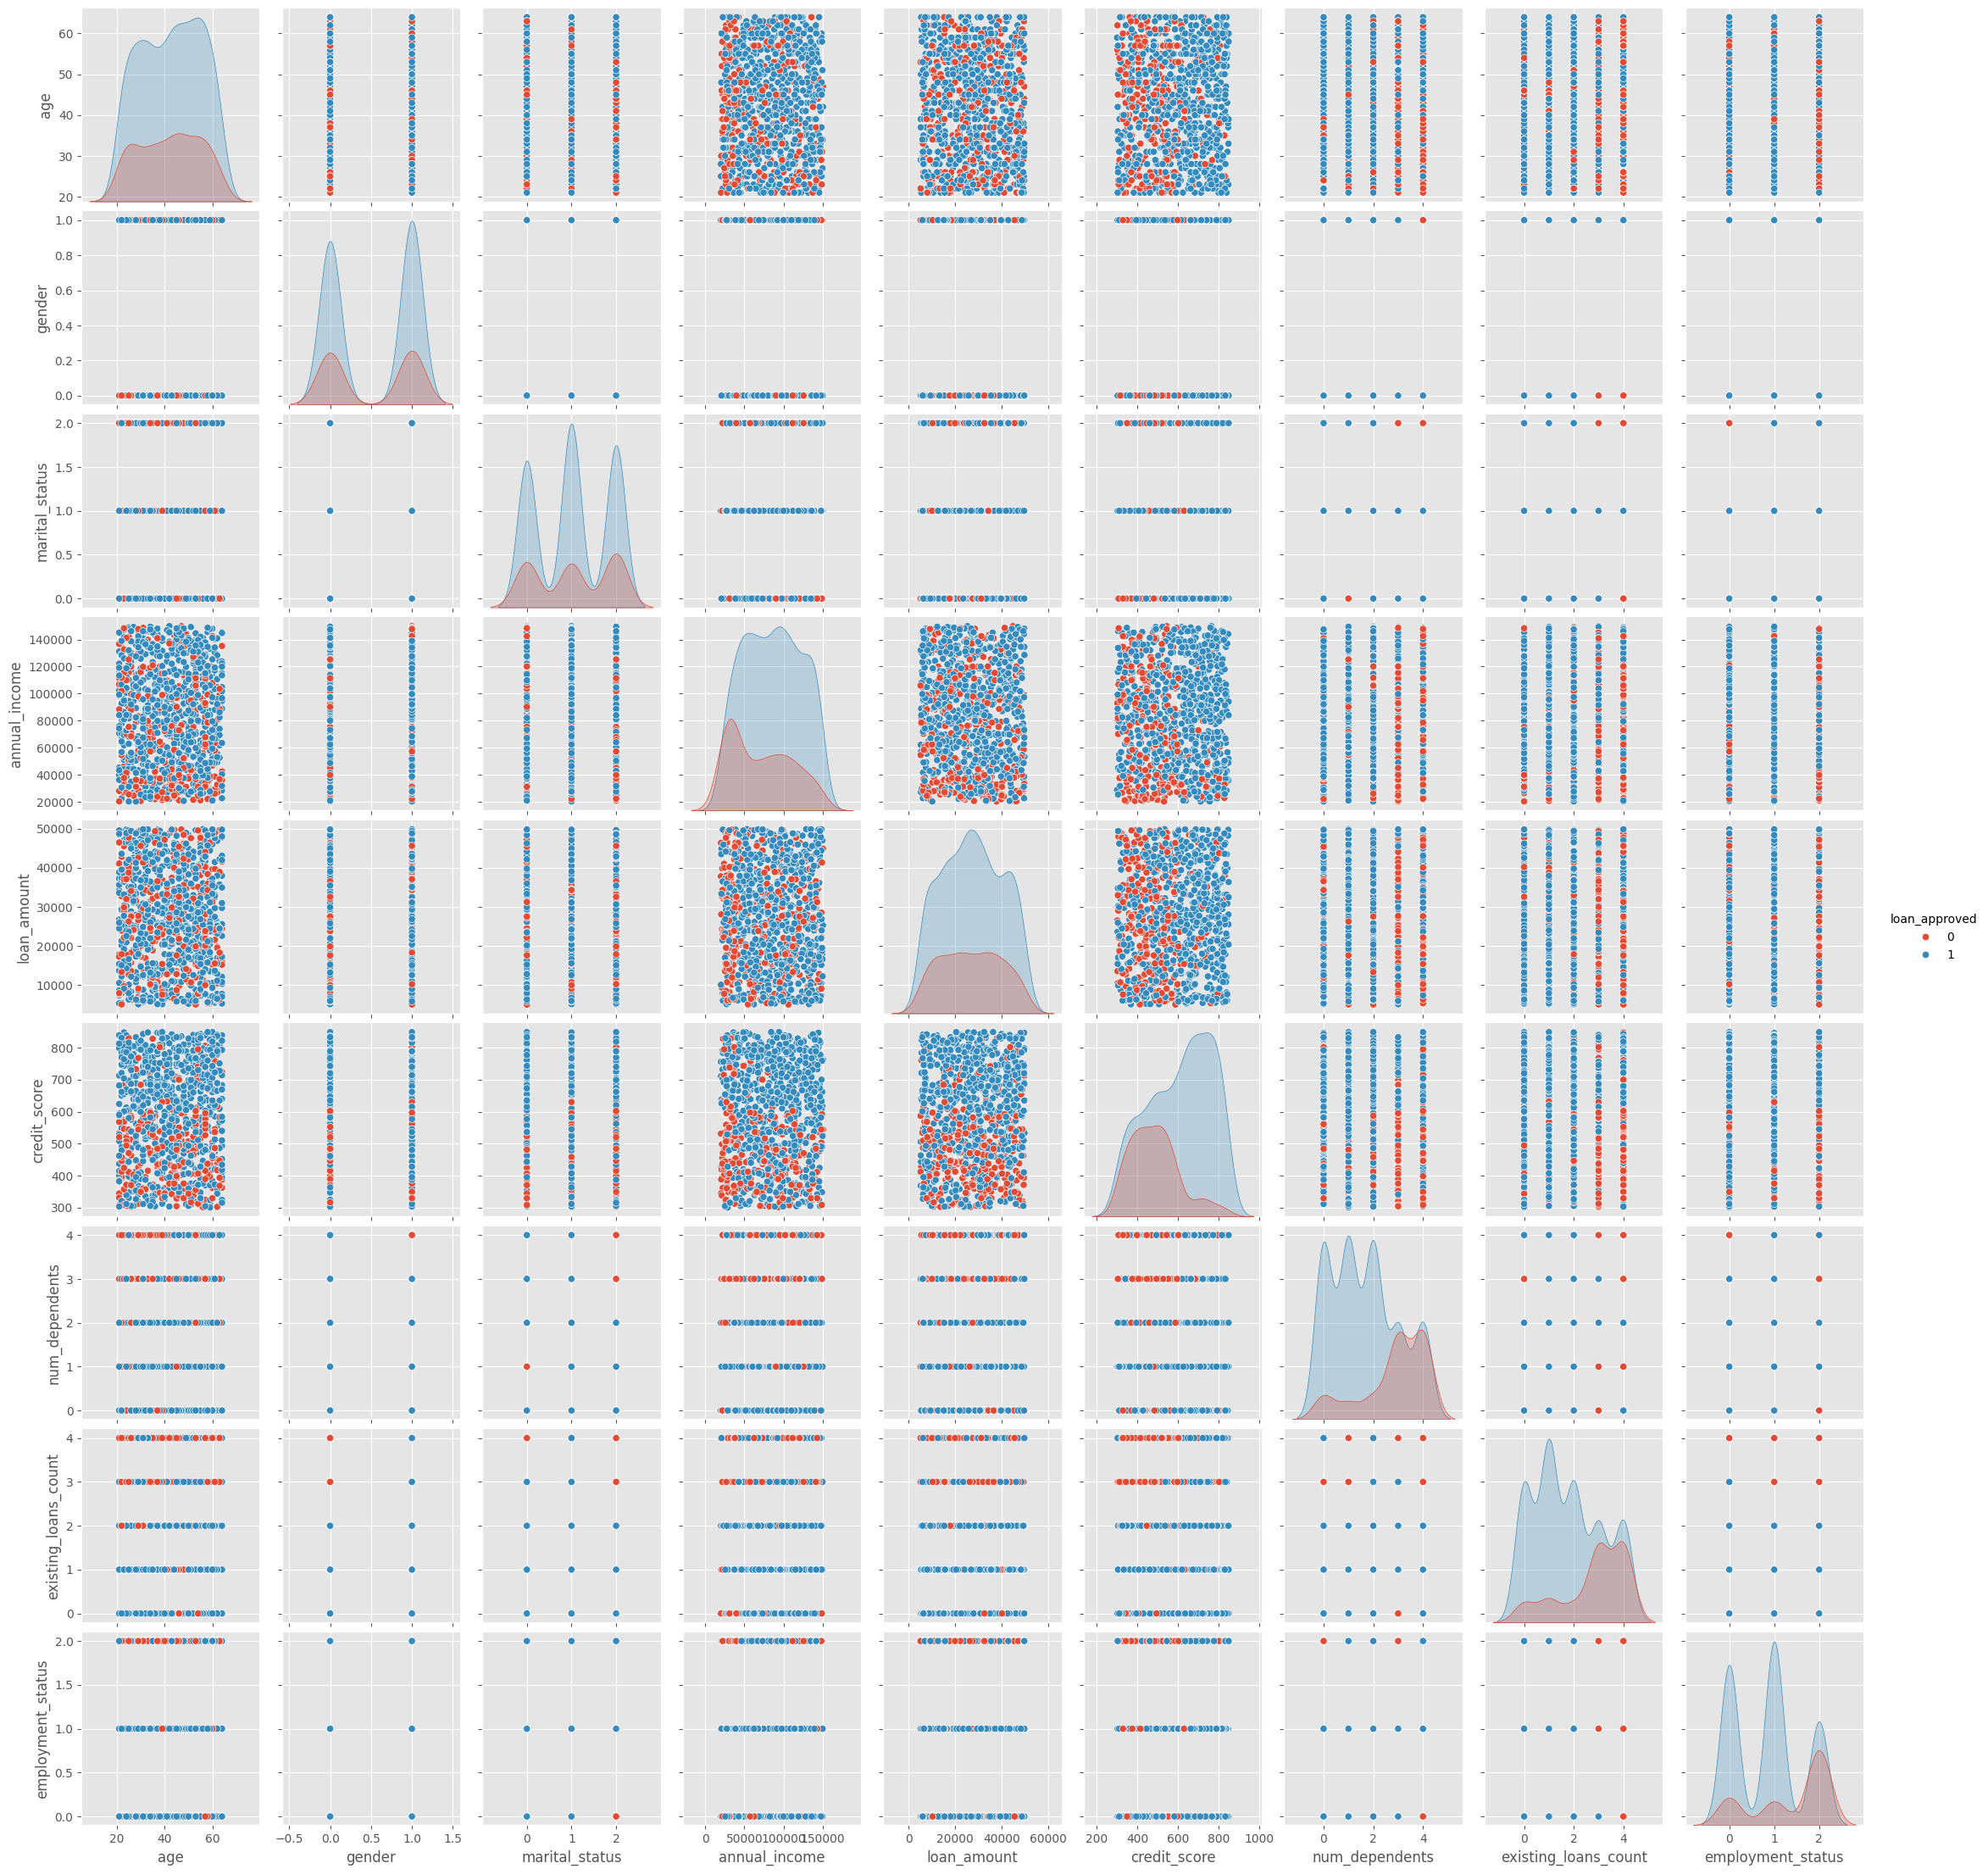

In [39]:
sns.pairplot(
    df_processed,
    hue="loan_approved"
)

plt.show()

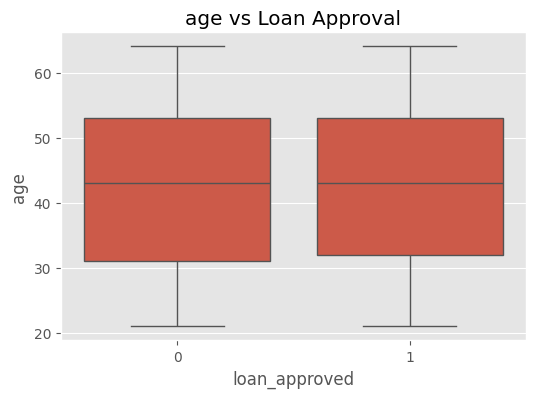

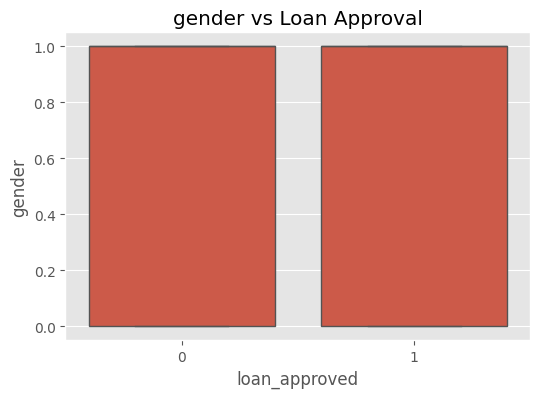

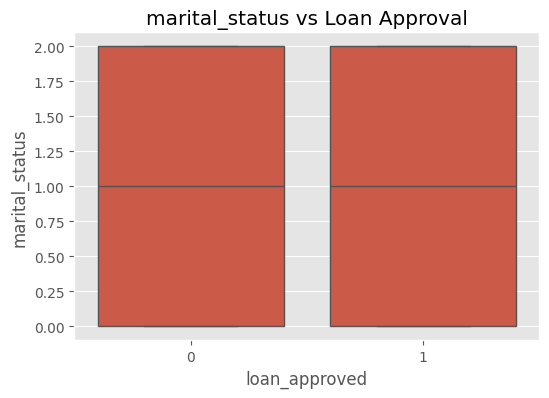

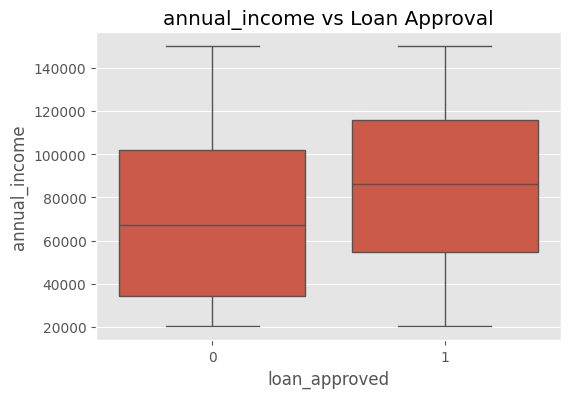

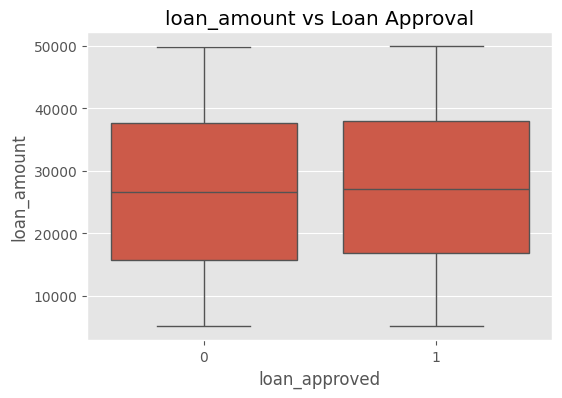

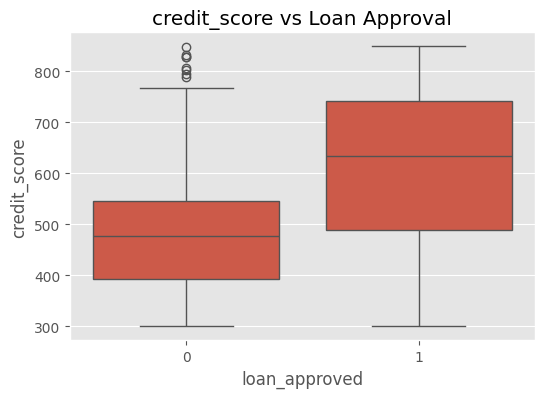

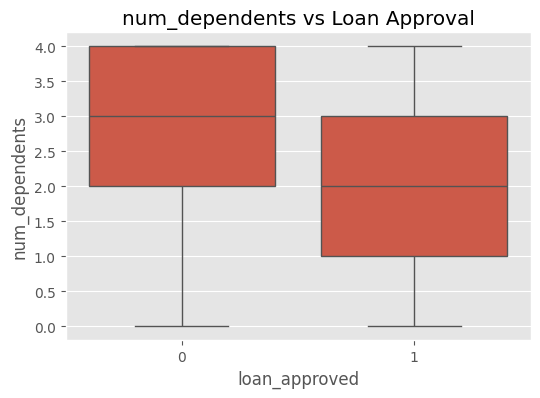

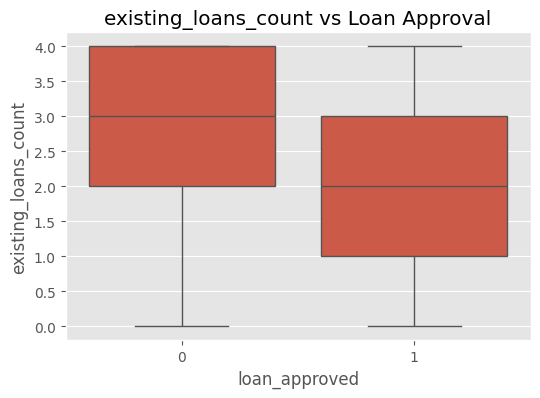

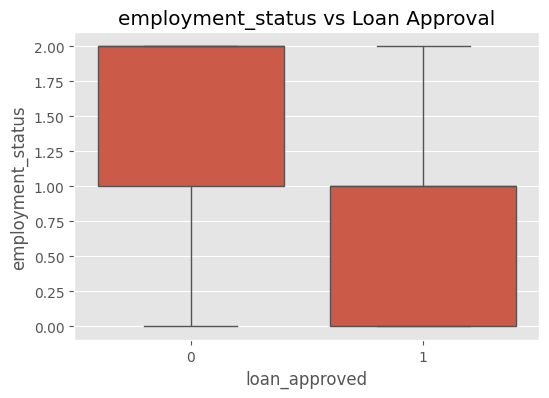

In [40]:
for col in numerical_columns:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        x="loan_approved",
        y=col,
        data=df_processed
    )

    plt.title(f"{col} vs Loan Approval")

    plt.show()

In [41]:
correlation = df_processed.corr()["loan_approved"].sort_values(ascending=False)

print(correlation)

loan_approved           1.000000
credit_score            0.351167
annual_income           0.176453
age                     0.020984
gender                  0.018038
loan_amount             0.015355
marital_status         -0.015232
employment_status      -0.277098
existing_loans_count   -0.324236
num_dependents         -0.365317
Name: loan_approved, dtype: float64


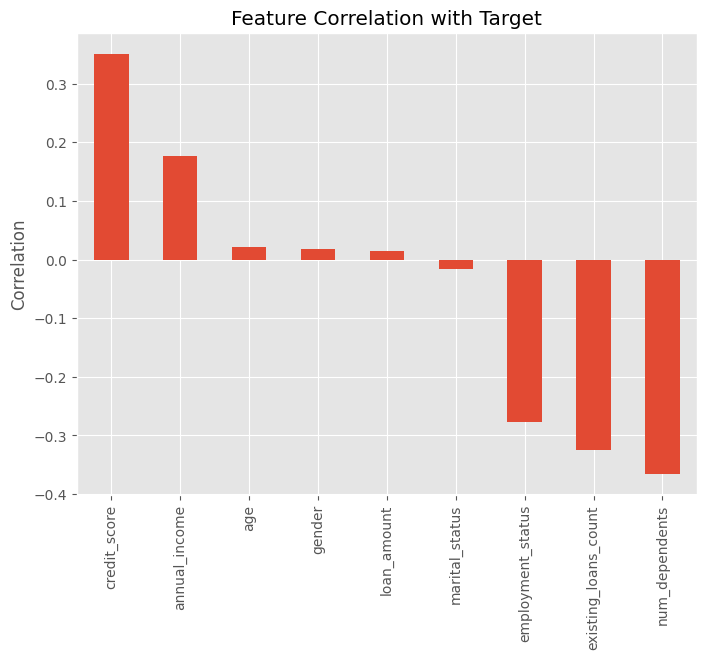

In [42]:
plt.figure(figsize=(8,6))

correlation.drop("loan_approved").plot(kind="bar")

plt.title("Feature Correlation with Target")

plt.ylabel("Correlation")

plt.show()

### EDA OBSEVATIONS

- Dataset contains 1000 records.
- No missing values were found.
- No duplicate rows were present.
- Applicant ID was removed before analysis.
- Dataset contains both numerical and categorical features (encoded).
- Target variable is binary.
- Feature distributions were analyzed.
- Correlation heatmap was generated.
- Outliers were inspected using boxplots.
- Relationships between features and the target were visualized.

In [43]:
# Train-Test Split
from sklearn.model_selection import train_test_split

# Feature Scaling
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier
)

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [44]:
X = df_processed.drop("loan_approved", axis=1)

y = df_processed["loan_approved"]

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [46]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [47]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(random_state=42),

    "Gradient Boosting": GradientBoostingClassifier(random_state=42),

    "AdaBoost": AdaBoostClassifier(random_state=42),

    "Extra Trees": ExtraTreesClassifier(random_state=42)
}

In [48]:
results = []

trained_models = {}

In [49]:
for name, model in models.items():

    # Tree models don't need scaling
    if name in [
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "AdaBoost",
        "Extra Trees"
    ]:

        model.fit(X_train, y_train)

        prediction = model.predict(X_test)

    else:

        model.fit(X_train_scaled, y_train)

        prediction = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, prediction)

    precision = precision_score(y_test, prediction)

    recall = recall_score(y_test, prediction)

    f1 = f1_score(y_test, prediction)

    trained_models[name] = model

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

In [50]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.860,0.873418,0.945205,0.907895
1,Decision Tree,0.990,0.986486,1.000000,0.993197
2,Random Forest,0.980,0.979730,0.993151,0.986395
3,Gradient Boosting,1.000,1.000000,1.000000,1.000000
4,AdaBoost,1.000,1.000000,1.000000,1.000000
5,Extra Trees,0.935,0.934641,0.979452,0.956522


In [51]:
results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,AdaBoost,1.000,1.000000,1.000000,1.000000
1,Gradient Boosting,1.000,1.000000,1.000000,1.000000
2,Decision Tree,0.990,0.986486,1.000000,0.993197
3,Random Forest,0.980,0.979730,0.993151,0.986395
4,Extra Trees,0.935,0.934641,0.979452,0.956522
5,Logistic Regression,0.860,0.873418,0.945205,0.907895


In [52]:
best_model_name = results_df.loc[0, "Model"]

print("Best Model :", best_model_name)

Best Model : AdaBoost


In [53]:
best_model = trained_models[best_model_name]

In [54]:
import os
import pickle

os.makedirs("saved_models", exist_ok=True)

with open("saved_models/best_model.pkl", "wb") as file:
    pickle.dump(best_model, file)

In [55]:
with open("saved_models/scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

In [56]:
results_df.to_csv(
    "saved_models/model_comparison.csv",
    index=False
)

In [57]:
print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0             AdaBoost     1.000   1.000000  1.000000  1.000000
1    Gradient Boosting     1.000   1.000000  1.000000  1.000000
2        Decision Tree     0.990   0.986486  1.000000  0.993197
3        Random Forest     0.980   0.979730  0.993151  0.986395
4          Extra Trees     0.935   0.934641  0.979452  0.956522
5  Logistic Regression     0.860   0.873418  0.945205  0.907895


In [58]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [59]:
tree_models = [
    "Decision Tree",
    "Random Forest",
    "Gradient Boosting",
    "AdaBoost",
    "Extra Trees"
]

if best_model_name in tree_models:
    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]
else:
    y_pred = best_model.predict(X_test_scaled)
    y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

In [60]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 54   0]
 [  0 146]]


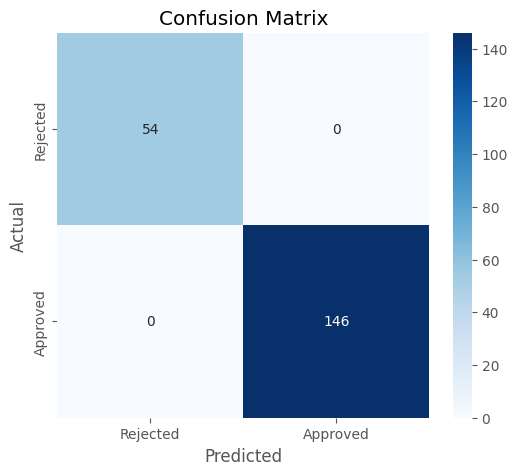

In [61]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Rejected","Approved"],
    yticklabels=["Rejected","Approved"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [62]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       1.00      1.00      1.00       146

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [63]:
roc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score :", round(roc_score,4))

ROC-AUC Score : 1.0


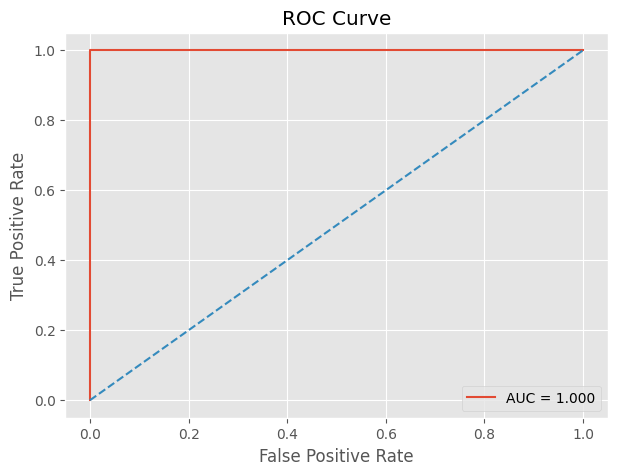

In [64]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_score:.3f}")

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

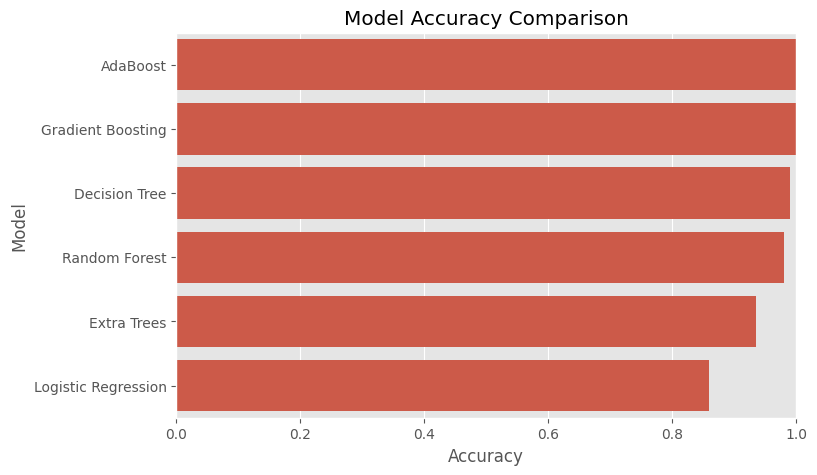

In [65]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model"
)

plt.title("Model Accuracy Comparison")

plt.xlim(0,1)

plt.show()

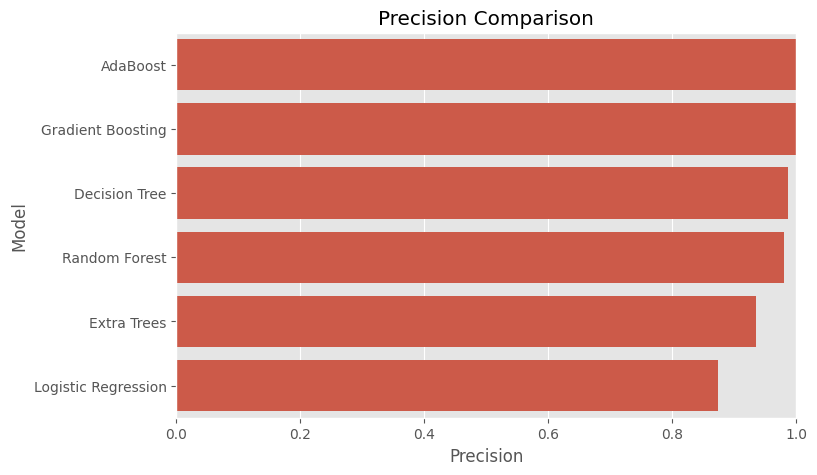

In [66]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Precision",
    y="Model"
)

plt.title("Precision Comparison")

plt.xlim(0,1)

plt.show()

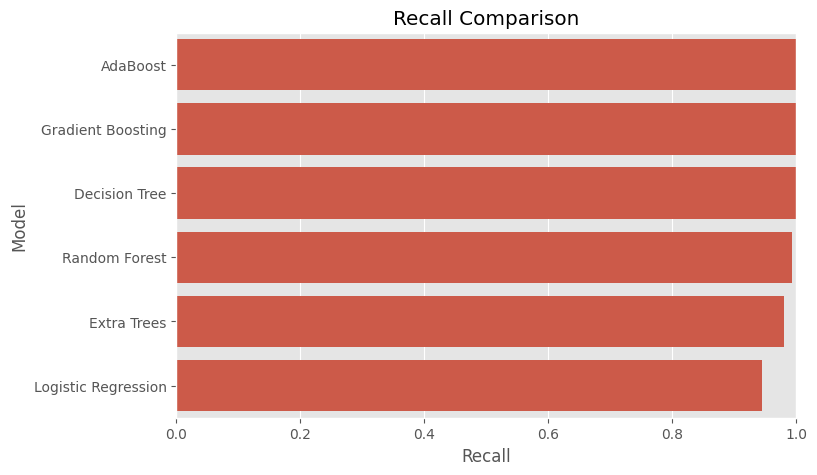

In [67]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Recall",
    y="Model"
)

plt.title("Recall Comparison")

plt.xlim(0,1)

plt.show()

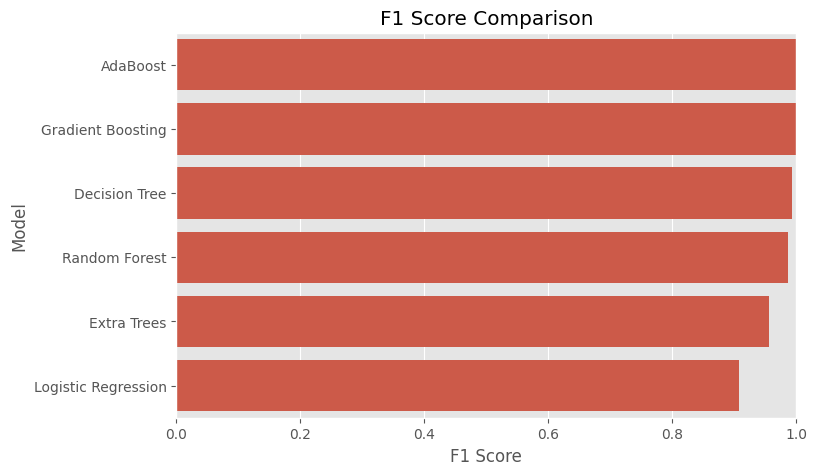

In [68]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="F1 Score",
    y="Model"
)

plt.title("F1 Score Comparison")

plt.xlim(0,1)

plt.show()

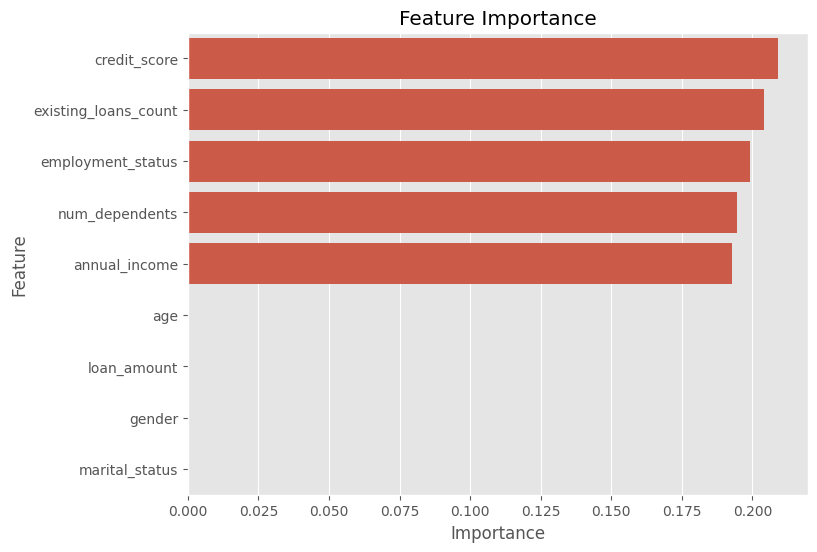

In [70]:
if hasattr(best_model, "feature_importances_"):

    importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": best_model.feature_importances_
    })

    importance = importance.sort_values(
        by="Importance",
        ascending=False
    )

    plt.figure(figsize=(8,6))

    sns.barplot(
        data=importance,
        x="Importance",
        y="Feature"
    )

    plt.title("Feature Importance")

    plt.show()

else:
    print("Feature Importance is not available for this model.")

In [71]:
if hasattr(best_model, "feature_importances_"):
    importance.to_csv(
        "saved_models/feature_importance.csv",
        index=False
    )